# 05. Сводные результаты и выводы

Этот ноутбук — материал для аспирантского доклада. Все цифры и графики уже посчитаны и сохранены в `artifacts/` скриптом `run_all.py`.

In [1]:
import sys, json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display, Markdown

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))
ART = ROOT / "artifacts"
FIG = ART / "figures"

split = json.loads((ART / "split_info.json").read_text(encoding="utf-8"))
display(Markdown(
    f"**Данные.** S&P 500, дневные log-доходности.  \n"
    f"Train: **{split['train_start']} — {split['train_end']}** ({split['n_train']} наблюдений)  \n"
    f"Test : **{split['test_start']} — {split['test_end']}** ({split['n_test']} наблюдений)"
))

**Данные.** S&P 500, дневные log-доходности.  
Train: **2010-01-05 — 2019-12-31** (2515 наблюдений)  
Test : **2020-01-02 — 2024-12-31** (1258 наблюдений)

## Таблица 1. Стилизованные факты: real vs synth

In [2]:
sf = pd.read_csv(ART / "stylized_facts.csv").set_index("name")
cols_sf = ["mean","std","skew","kurtosis_excess","min","max",
           "acf1_returns","acf1_abs_returns","acf5_abs_returns","acf10_abs_returns"]
sf[cols_sf].round(4)

,mean,std,skew,kurtosis_excess,min,max,acf1_returns,acf1_abs_returns,acf5_abs_returns,acf10_abs_returns
name,,,,,,,,,,
real_train,0.0417,0.9317,-0.4970,4.5970,-6.8958,4.8403,-0.0462,0.2138,0.2013,0.2003
synth_timegan,-0.0238,0.9312,-0.0516,-1.5665,-1.7843,1.4272,-0.7411,0.2101,-0.0243,0.0114
synth_ctgan,-0.0001,1.3667,-0.5355,3.5827,-8.6638,7.1449,-0.0502,-0.0074,0.0016,-0.0367


## Таблица 2. Параметры GARCH(1,1)-t по веткам

In [3]:
summary = pd.read_csv(ART / "metrics_summary.csv")
p_cols = ["branch","mu","omega","alpha","beta","nu"]
p_view = summary[p_cols].copy()
p_view["alpha+beta"] = p_view["alpha"] + p_view["beta"]
p_view.set_index("branch").round(5)

,mu,omega,alpha,beta,nu,alpha+beta
branch,,,,,,
B1_real,0.08679,0.02529,0.17588,0.81256,4.87385,0.98844
B2_timegan,-0.02880,0.69348,0.20255,0.00000,499.98079,0.20255
B2_ctgan,0.05030,1.18216,0.00000,0.44199,3.34960,0.44199
B3_aug,0.03363,0.03069,0.14103,0.82611,75.95990,0.96713


## Таблица 3. Метрики прогноза волатильности (на real test 2020–2024)

In [4]:
m_cols = ["branch","RMSE_abs_r","MAE_abs_r","QLIKE","MZ_a","MZ_b","MZ_R2",
          "VaR5_violations","VaR5_rate","VaR5_kupiec_p",
          "VaR1_violations","VaR1_rate","VaR1_kupiec_p"]
summary[m_cols].set_index("branch").round(4)

,RMSE_abs_r,MAE_abs_r,QLIKE,MZ_a,MZ_b,MZ_R2,VaR5_violations,VaR5_rate,VaR5_kupiec_p,VaR1_violations,VaR1_rate,VaR1_kupiec_p
branch,,,,,,,,,,,,
B1_real,0.8867,0.6334,1.0898,1.645000e-01,9.002000e-01,0.3042,99,0.0787,0.0000,20,0.0159,0.0528
B2_timegan,0.9378,0.6444,1.4460,-7.465000e-01,2.419200e+00,0.2401,91,0.0723,0.0006,44,0.0350,0.0000
B2_ctgan,1.1682,0.9231,1.6098,-1.870464e+12,8.829097e+11,0.3265,57,0.0453,0.4383,12,0.0095,0.8685
B3_aug,0.8686,0.6197,1.0896,9.030000e-02,1.048600e+00,0.2990,84,0.0668,0.0093,32,0.0254,0.0000


## Графики

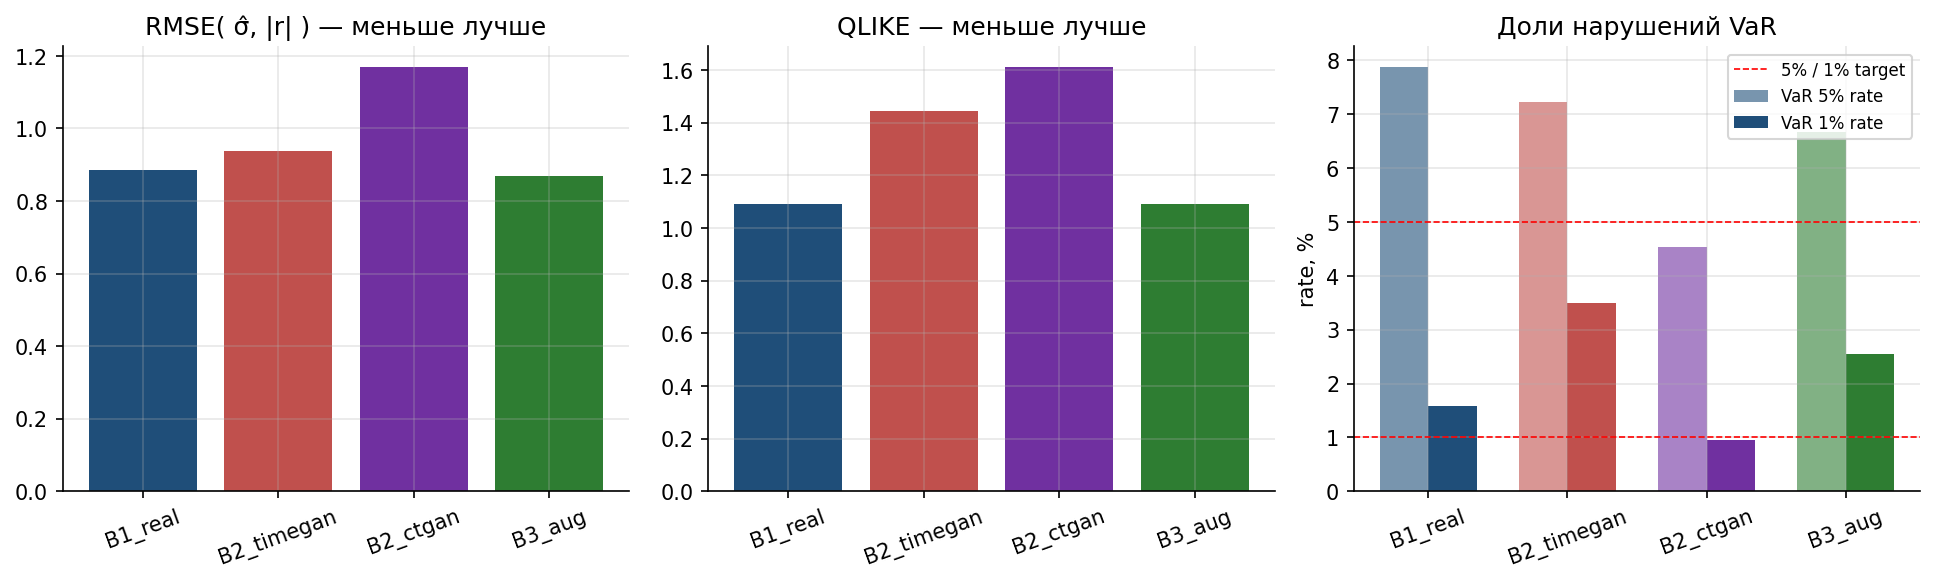

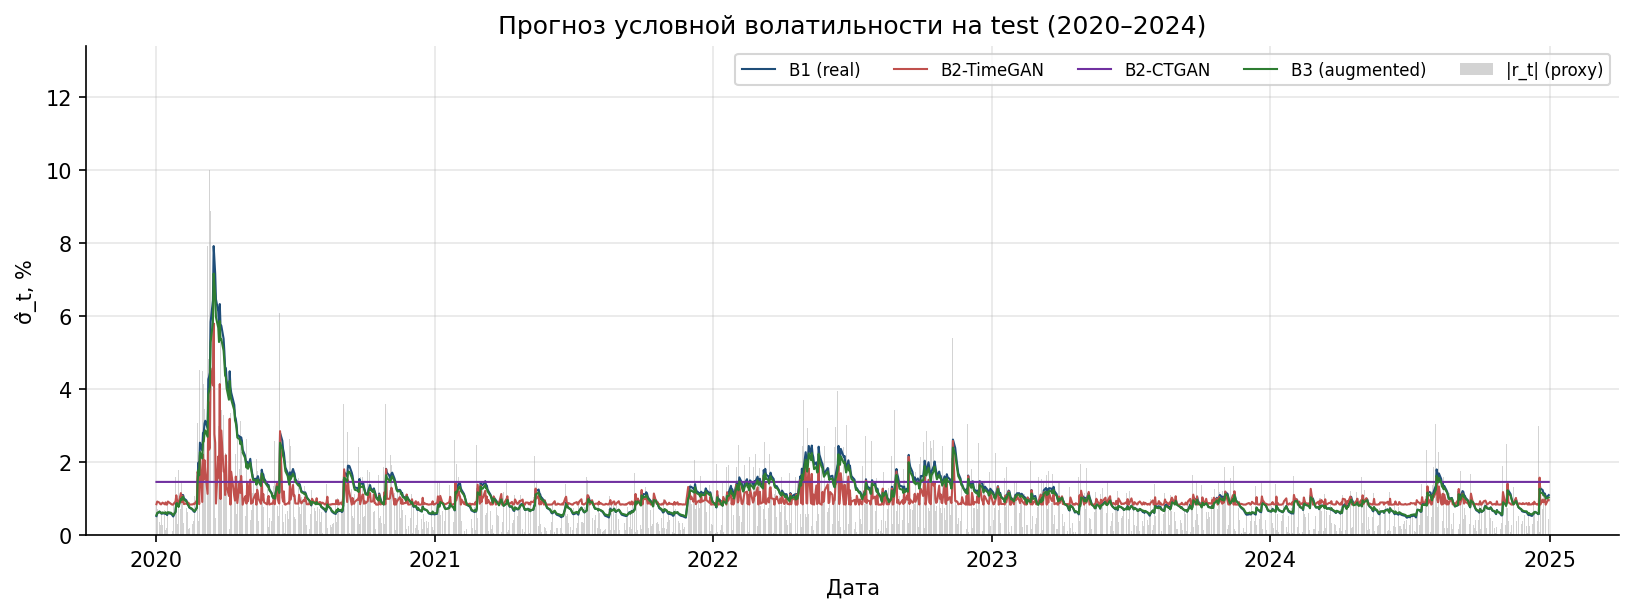

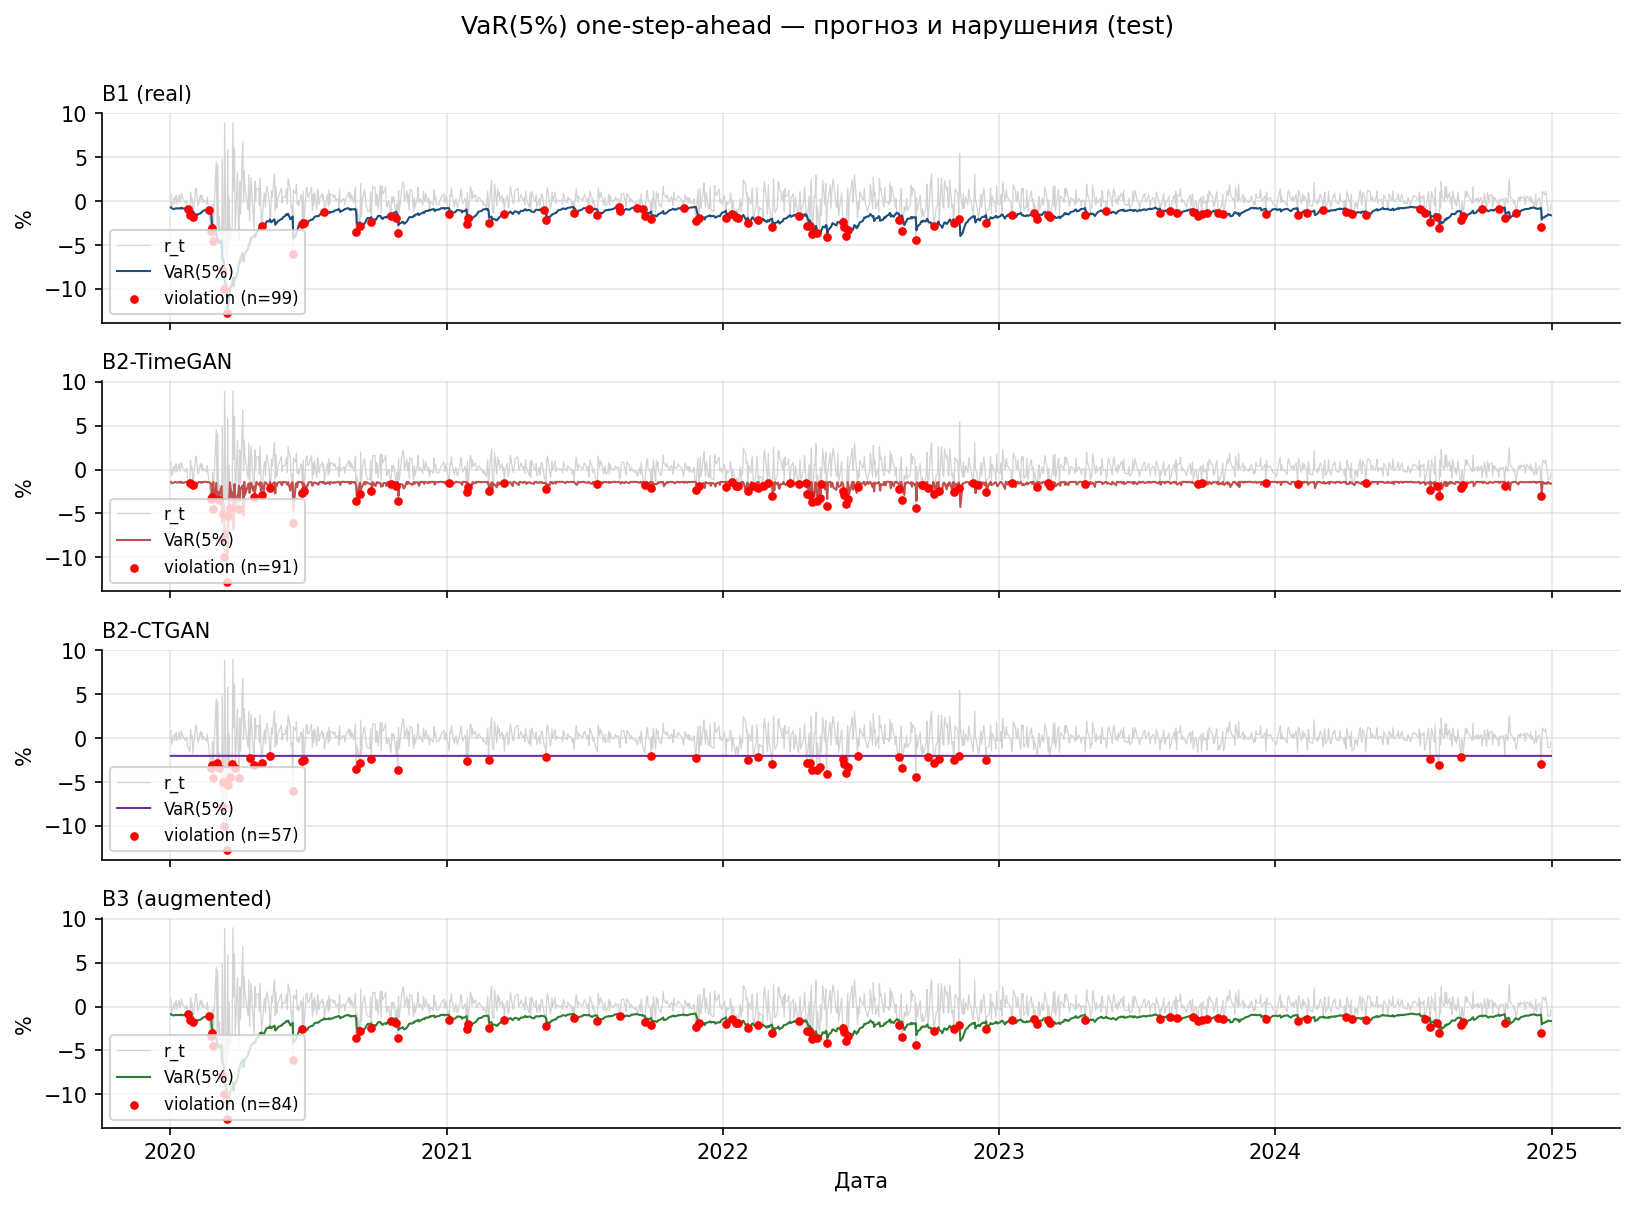

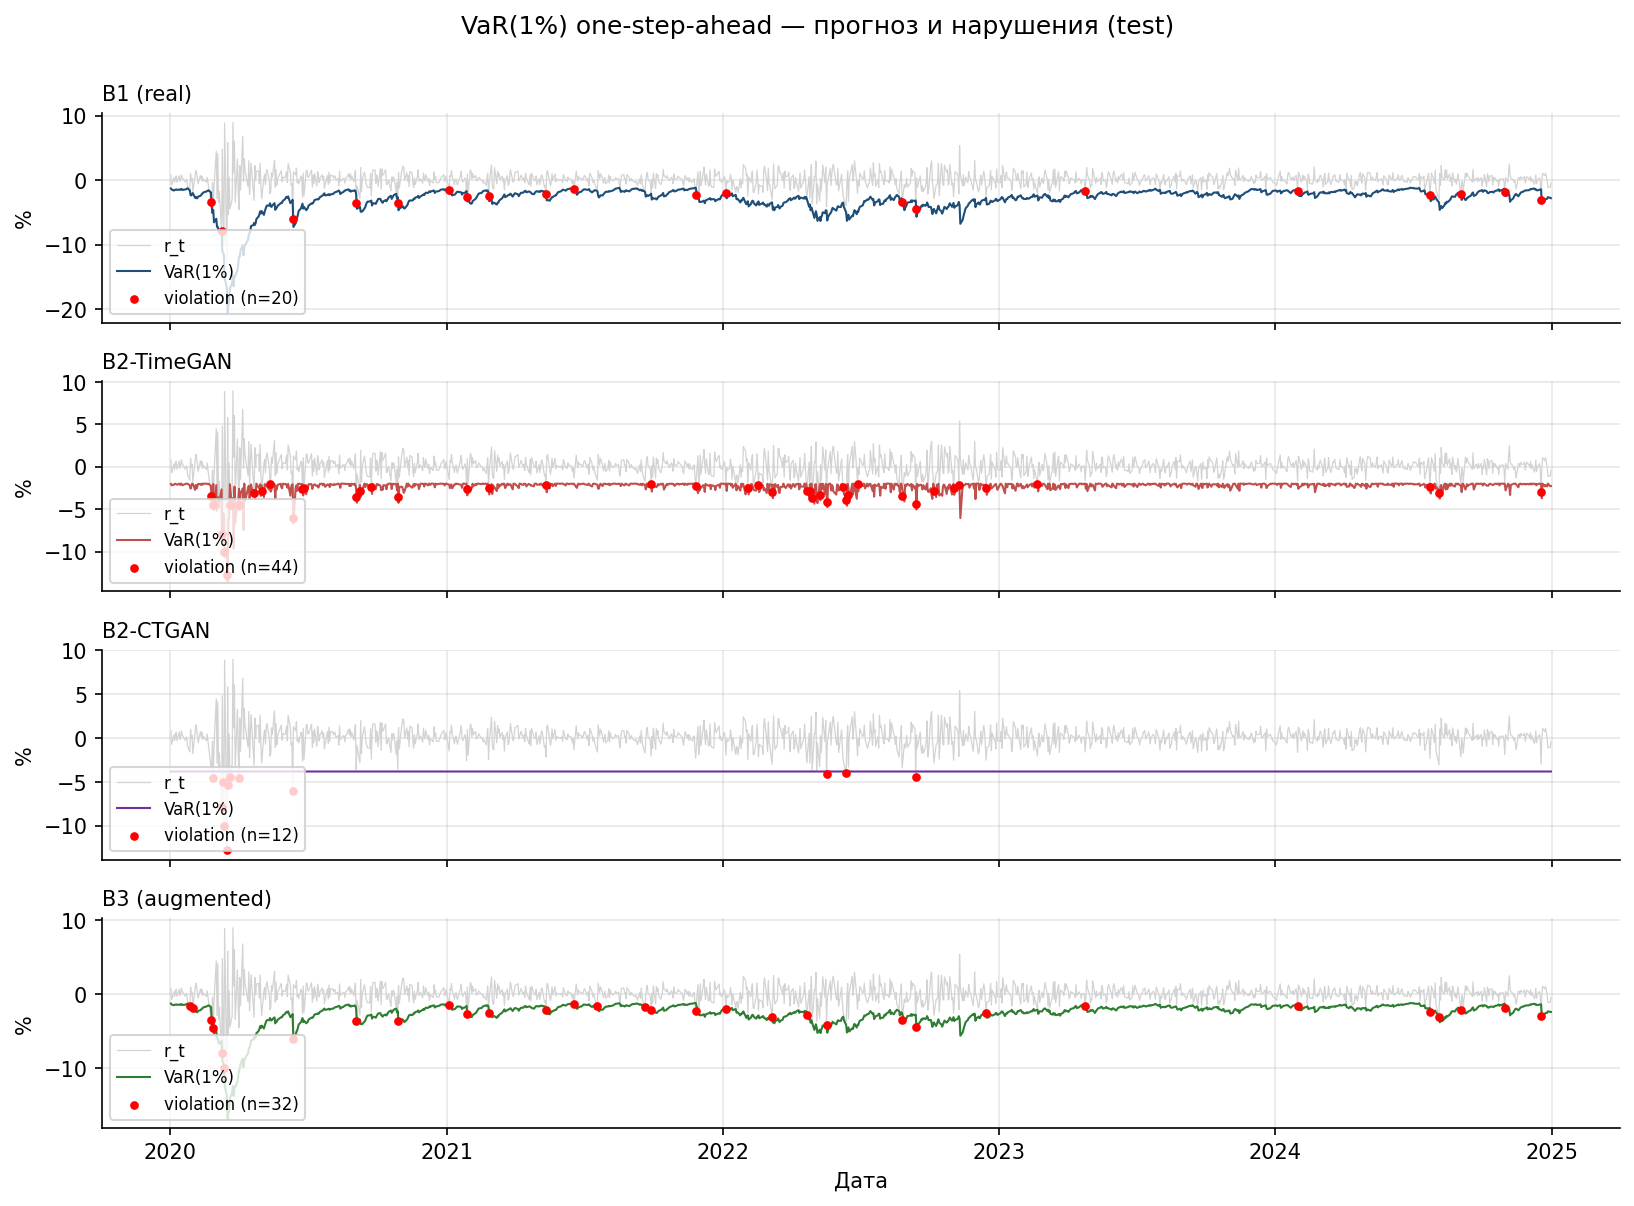

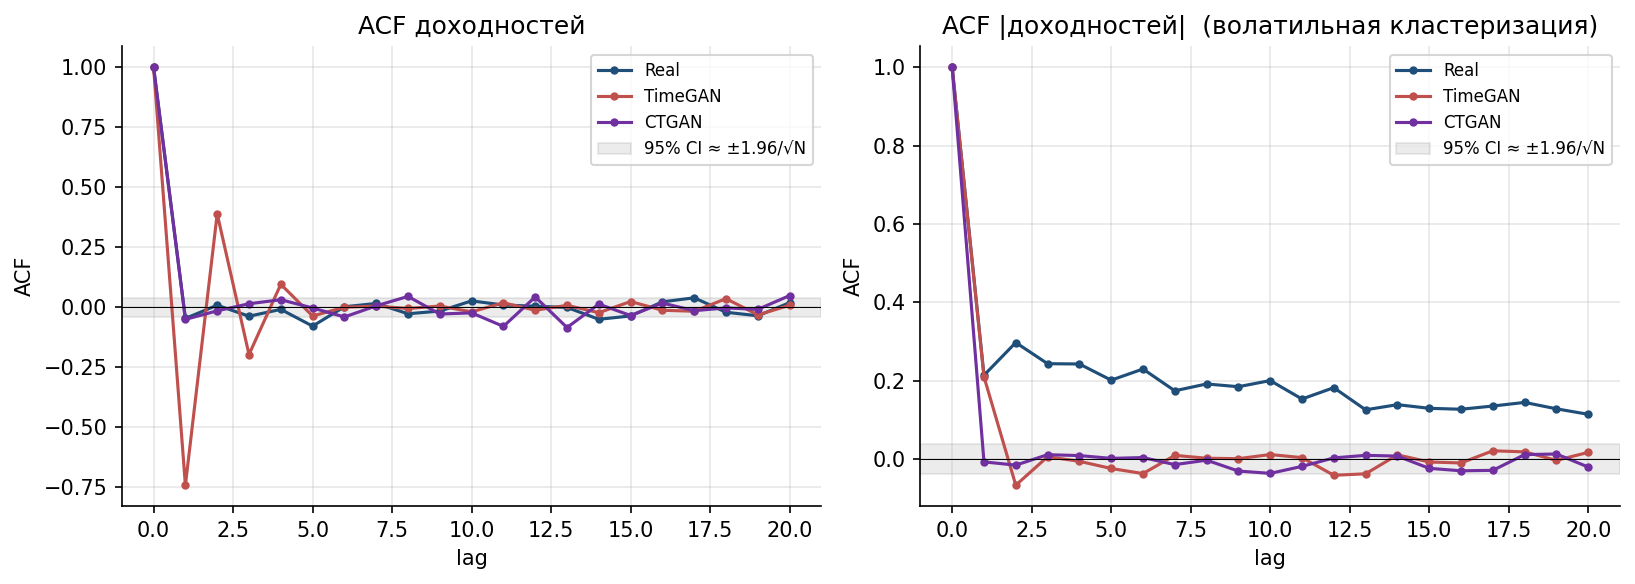

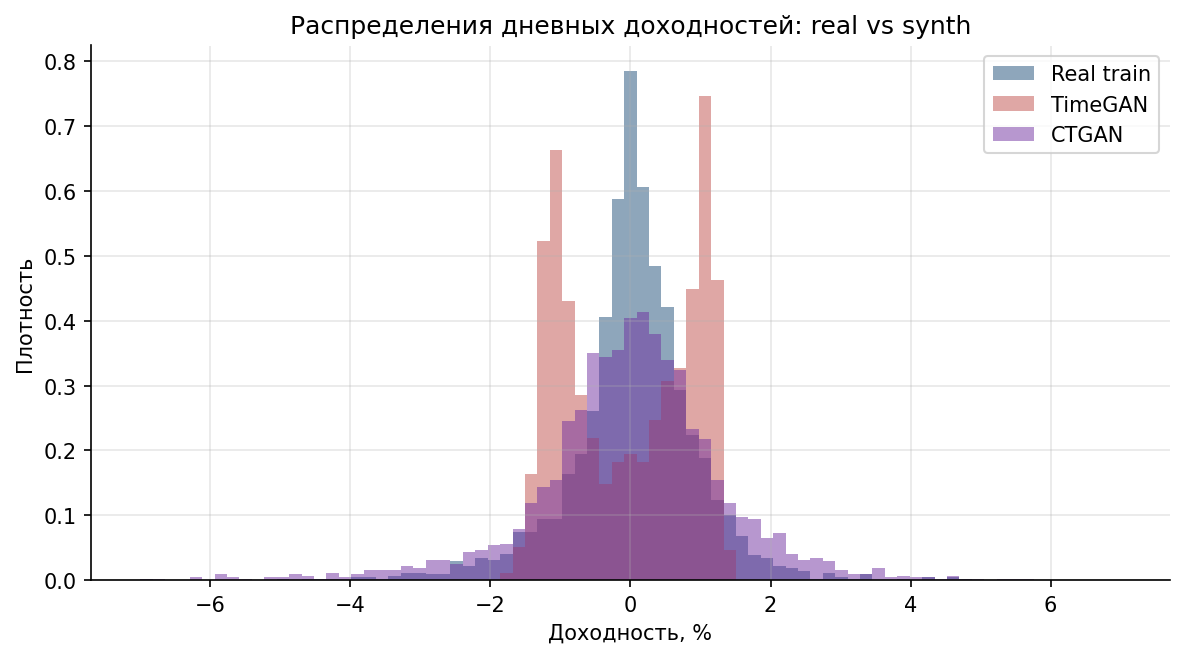

In [5]:
display(Image(filename=str(FIG / "07_metrics_bars.png")))
display(Image(filename=str(FIG / "05_volatility_forecasts.png")))
display(Image(filename=str(FIG / "06_var_violations_5.png")))
display(Image(filename=str(FIG / "06_var_violations_1.png")))
display(Image(filename=str(FIG / "04_acf_compare.png")))
display(Image(filename=str(FIG / "03_distributions.png")))

## Выводы для доклада

**По Q1 (TSTR — синтетика как замена реальных данных).**
Полная замена train на синтетику ухудшает прогноз GARCH даже при использовании специализированного TimeGAN. Главное наблюдение — TimeGAN сохранил кластеризацию волатильности на коротком лаге (ACF |r|, lag 1 ≈ 0.21 ≈ как у real), но обрезал распределение хвостов и потерял структуру на средних лагах (ACF на лаге 5–10 ≈ 0). В результате обученный на этой синтетике GARCH(1,1)-t получает β ≈ 0 — теряет память о шоках. На стресс-периоде 2020–2024 это даёт RMSE на 6% хуже baseline и **долю нарушений VaR(1%) 3.5% против ожидаемых 1%** (Kupiec p < 1e-11). CTGAN, использованный «по-табличному», ломает временную структуру ещё сильнее: α ≈ 0, GARCH перестаёт быть GARCH'ом.

**По Q2 (Augmentation — синтетика как продолжение реальных).**
Конкатенация `synth_TimeGAN + real train` (5030 точек вместо 2515) даёт **умеренное улучшение** прогноза по нескольким независимым метрикам сразу: RMSE 0.869 vs 0.887, MZ-наклон 1.05 vs 0.90 (ближе к идеальному 1.0), доля нарушений VaR(5%) 6.7% vs 7.9%. Persistence α+β ≈ 0.97 сохраняется. Эффект небольшой, но систематический. На VaR(1%) аугментация ухудшает результат — здесь сигнал смешан.

**Общий вывод.** Синтетические данные от GAN в задаче моделирования волатильности **не могут заменить реальные**, но **могут осторожно дополнять** их, особенно если приоритет — калибровка прогноза условной волатильности и VaR(5%). Качество дополнения напрямую упирается в способность GAN воспроизводить стилизованные факты — в первую очередь долгую память в |r_t| и тяжёлые хвосты. CTGAN для этой задачи неприменим в принципе; TimeGAN полезен ограниченно.

**Ограничения работы.** (1) Один индекс (S&P 500). (2) Один тип GAN-архитектуры (упрощённый TimeGAN с BCE-loss). (3) GARCH(1,1) — не GJR/EGARCH, не учитывается leverage. (4) Walk-forward с фиксированными параметрами; полный refit на каждом шаге не делался по соображениям времени.